# Executive Summary

This analysis explores labor market dynamics in the Netherlands to identify potential drivers of absenteeism. While workload per employee remains stable over time, labor costs and employer-paid social premiums have increased significantly. These trends suggest that absenteeism risk is more likely driven by structural labor market pressures—such as wage inflation and rising indirect costs—rather than increasing working hours.

# Cleaning 85917NED Data



## 1. Import required libraries

In [1]:
# Import required libraries
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

## 2. Reading the table from Silver Database

In [3]:
# Path to the silver database
db_path = Path("../../data/2_silver/silver_data.db")

# Connect to the database
conn = sqlite3.connect(db_path)
print(f"Connected to {db_path}")

# List available tables
tables = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table';", conn
)
print("Available tables:", tables["name"].tolist())

# Read the table (IMPORTANT: quote table name because it starts with a number)
table_name = "85917NED_silver"

df_85917NED = pd.read_sql_query(
    f'SELECT * FROM "{table_name}"',
    conn
)

print(f"Loaded {len(df_85917NED)} rows from {table_name}")
display(df_85917NED.head())

# 1️⃣ Column names
print(df_85917NED.columns.tolist())

# 2️⃣ Data types
print(df_85917NED.dtypes)

# 3️⃣ Compact summary (best overview)
df_85917NED.info()

# 5️⃣ Unique values per column (optional but useful)
for col in df_85917NED.columns:
    print(f"\n{col}:")
    print(df_85917NED[col].unique()[:10])

Connected to ..\..\data\2_silver\silver_data.db
Available tables: ['85916NED_silver_SH', '80072ned_silver', '83415NED_silver', '85916NED_silver', '85917NED_silver', '85918NED_silver', '85919NED_silver', '85920NED_silver']
Loaded 2464 rows from 85917NED_silver


,silver_id,bronze_pk,ID,BedrijfstakkenBranchesSBI2008,Perioden,BeloningVanWerknemers_1,BeloningSeizoengecorrigeerd_2,Lonen_3,LonenSeizoengecorrigeerd_4,SocialePremiesTLVWerkgevers_5,...,Totaal_30,Mannen_31,Vrouwen_32,_source_file,BedrijfstakkenBranchesSBI2008_Title,BedrijfstakkenBranchesSBI2008_Description,BedrijfstakkenBranchesSBI2008_CategoryGroupID,Perioden_Title,Perioden_Description,Perioden_Status
0,1,TypedDataSet.json_0,0,T001081,1995KW01,38433.0,40204.0,31827.0,33627.0,6606.0,...,None,None,None,TypedDataSet.json,A-U Alle economische activiteiten,Alle economische activiteiten\r\nDeze categori...,None,1995 1e kwartaal,,Definitief
1,2,TypedDataSet.json_1,1,T001081,1995KW02,46140.0,41191.0,39378.0,34562.0,6762.0,...,None,None,None,TypedDataSet.json,A-U Alle economische activiteiten,Alle economische activiteiten\r\nDeze categori...,None,1995 2e kwartaal,,Definitief
2,3,TypedDataSet.json_2,2,T001081,1995KW03,39269.0,41735.0,32724.0,35059.0,6545.0,...,None,None,None,TypedDataSet.json,A-U Alle economische activiteiten,Alle economische activiteiten\r\nDeze categori...,None,1995 3e kwartaal,,Definitief
3,4,TypedDataSet.json_3,3,T001081,1995KW04,41718.0,42475.0,35021.0,35743.0,6697.0,...,None,None,None,TypedDataSet.json,A-U Alle economische activiteiten,Alle economische activiteiten\r\nDeze categori...,None,1995 4e kwartaal,,Definitief
4,5,TypedDataSet.json_4,4,T001081,1995JJ00,165560.0,None,138950.0,None,26610.0,...,None,None,None,TypedDataSet.json,A-U Alle economische activiteiten,Alle economische activiteiten\r\nDeze categori...,None,1995,,Definitief


['silver_id', 'bronze_pk', 'ID', 'BedrijfstakkenBranchesSBI2008', 'Perioden', 'BeloningVanWerknemers_1', 'BeloningSeizoengecorrigeerd_2', 'Lonen_3', 'LonenSeizoengecorrigeerd_4', 'SocialePremiesTLVWerkgevers_5', 'SocialePremiesSeizoengecorrigeerd_6', 'Loonkosten_7', 'BeloningVanWerknemers_8', 'Lonen_9', 'Loonkosten_10', 'BeloningPerArbeidsjaar_11', 'LonenPerArbeidsjaar_12', 'LoonkostenPerArbeidsjaar_13', 'BeloningPerGewerktUur_14', 'LonenPerGewerktUur_15', 'LoonkostenPerGewerktUur_16', 'BeloningPerArbeidsjaar_17', 'LonenPerArbeidsjaar_18', 'LoonkostenPerArbeidsjaar_19', 'BeloningPerGewerktUur_20', 'LonenPerGewerktUur_21', 'LoonkostenPerGewerktUur_22', 'Arbeidsjaren_23', 'GewerkteUren_24', 'Arbeidsjaren_25', 'GewerkteUren_26', 'Totaal_27', 'Mannen_28', 'Vrouwen_29', 'Totaal_30', 'Mannen_31', 'Vrouwen_32', '_source_file', 'BedrijfstakkenBranchesSBI2008_Title', 'BedrijfstakkenBranchesSBI2008_Description', 'BedrijfstakkenBranchesSBI2008_CategoryGroupID', 'Perioden_Title', 'Perioden_Descrip

## 3. Data Cleaning

### Standardize column data types for the full table

In [4]:
# --- Standardize column data types for 85917NED ---


# 1. Convert key / ID columns
df_85917NED["silver_id"] = df_85917NED["silver_id"].astype("int64")
df_85917NED["bronze_pk"] = df_85917NED["bronze_pk"].astype("string")
df_85917NED["ID"] = df_85917NED["ID"].astype("string")


# 2. Convert dimension code columns
dim_cols = [
    "BedrijfstakkenBranchesSBI2008",
    "Perioden"
]

df_85917NED[dim_cols] = df_85917NED[dim_cols].astype("string")


# 3. Convert descriptive text columns
text_cols = [
    "BedrijfstakkenBranchesSBI2008_Title",
    "BedrijfstakkenBranchesSBI2008_Description",
    "Perioden_Title",
    "Perioden_Description",
    "Perioden_Status",
    "_source_file"
]

df_85917NED[text_cols] = df_85917NED[text_cols].astype("string")


# 4. Convert numeric CBS variables
numeric_cols = [
    # --- Absolute values ---
    "BeloningVanWerknemers_1",
    "BeloningSeizoengecorrigeerd_2",
    "Lonen_3",
    "LonenSeizoengecorrigeerd_4",
    "SocialePremiesTLVWerkgevers_5",
    "SocialePremiesSeizoengecorrigeerd_6",
    "Loonkosten_7",

    # --- YoY growth (will drop later but convert now) ---
    "BeloningVanWerknemers_8",
    "Lonen_9",
    "Loonkosten_10",

    # --- Per FTE / per hour ---
    "BeloningPerArbeidsjaar_11",
    "LonenPerArbeidsjaar_12",
    "LoonkostenPerArbeidsjaar_13",
    "BeloningPerGewerktUur_14",
    "LonenPerGewerktUur_15",
    "LoonkostenPerGewerktUur_16",

    # --- YoY of per metrics ---
    "BeloningPerArbeidsjaar_17",
    "LonenPerArbeidsjaar_18",
    "LoonkostenPerArbeidsjaar_19",
    "BeloningPerGewerktUur_20",
    "LonenPerGewerktUur_21",
    "LoonkostenPerGewerktUur_22",

    # --- Labour volume ---
    "Arbeidsjaren_23",
    "GewerkteUren_24",

    # --- YoY labour volume ---
    "Arbeidsjaren_25",
    "GewerkteUren_26",

    # --- Jobs ---
    "Totaal_27",
    "Mannen_28",
    "Vrouwen_29",

    # --- YoY jobs ---
    "Totaal_30",
    "Mannen_31",
    "Vrouwen_32"
]

df_85917NED[numeric_cols] = df_85917NED[numeric_cols].apply(
    pd.to_numeric, errors="coerce"
)


# 5. Convert remaining category columns
remaining_cols = [
    "BedrijfstakkenBranchesSBI2008_CategoryGroupID"
]

df_85917NED[remaining_cols] = df_85917NED[remaining_cols].astype("string")


# 6. Final check
df_85917NED.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2464 entries, 0 to 2463
Data columns (total 44 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   silver_id                                      2464 non-null   int64  
 1   bronze_pk                                      2464 non-null   string 
 2   ID                                             2464 non-null   string 
 3   BedrijfstakkenBranchesSBI2008                  2464 non-null   string 
 4   Perioden                                       2464 non-null   string 
 5   BeloningVanWerknemers_1                        2448 non-null   float64
 6   BeloningSeizoengecorrigeerd_2                  1968 non-null   float64
 7   Lonen_3                                        2448 non-null   float64
 8   LonenSeizoengecorrigeerd_4                     1968 non-null   float64
 9   SocialePremiesTLVWerkgevers_5                  2448 

### Convert CBS Perioden codes into datetime + frequency

In [5]:
# --- Standard CBS Perioden → time dimension conversion (consistent across tables) ---


# 1. Determine frequency
df_85917NED["frequency"] = np.select(
    [
        df_85917NED["Perioden"].str.contains("KW"),
        df_85917NED["Perioden"].str.contains("MM"),
        df_85917NED["Perioden"].str.contains("JJ")
    ],
    [
        "quarterly",
        "monthly",
        "annual"
    ],
    default="unknown"
)


# 2. Extract year
df_85917NED["year"] = df_85917NED["Perioden"].str[:4].astype(int)


# 3. Extract quarter
df_85917NED["quarter"] = df_85917NED["Perioden"].str.extract(r"KW(\d{2})")[0]
df_85917NED["quarter"] = pd.to_numeric(df_85917NED["quarter"], errors="coerce")


# 4. Create empty datetime column
df_85917NED["period_enddate"] = pd.NaT


# --- Quarterly periods ---
mask_q = df_85917NED["frequency"] == "quarterly"

df_85917NED.loc[mask_q, "period_enddate"] = (
    pd.PeriodIndex.from_fields(
        year=df_85917NED.loc[mask_q, "year"],
        quarter=df_85917NED.loc[mask_q, "quarter"].astype(int)
    )
    .to_timestamp(how="end")
)


# --- Annual periods ---
mask_y = df_85917NED["frequency"] == "annual"

df_85917NED.loc[mask_y, "period_enddate"] = pd.to_datetime(
    df_85917NED.loc[mask_y, "year"].astype(str) + "-12-31"
)


# --- Monthly periods (future-proof, even if unused) ---
mask_m = df_85917NED["frequency"] == "monthly"

month = df_85917NED.loc[mask_m, "Perioden"].str.extract(r"MM(\d{2})")[0]
month = pd.to_numeric(month, errors="coerce")

df_85917NED.loc[mask_m, "period_enddate"] = (
    pd.to_datetime(dict(
        year=df_85917NED.loc[mask_m, "year"],
        month=month,
        day=1
    )) + pd.offsets.MonthEnd(0)
)


# 5. Clean timestamp precision
df_85917NED["period_enddate"] = pd.to_datetime(
    df_85917NED["period_enddate"]
).dt.normalize()


# 6. Convert quarter to nullable integer
df_85917NED["quarter"] = df_85917NED["quarter"].astype("Int64")


# 7. Check result
df_85917NED[["Perioden", "frequency", "year", "quarter", "period_enddate"]].head(10)

,Perioden,frequency,year,quarter,period_enddate
0,1995KW01,quarterly,1995,1,1995-03-31
1,1995KW02,quarterly,1995,2,1995-06-30
2,1995KW03,quarterly,1995,3,1995-09-30
3,1995KW04,quarterly,1995,4,1995-12-31
4,1995JJ00,annual,1995,<NA>,1995-12-31
5,1996KW01,quarterly,1996,1,1996-03-31
6,1996KW02,quarterly,1996,2,1996-06-30
7,1996KW03,quarterly,1996,3,1996-09-30
8,1996KW04,quarterly,1996,4,1996-12-31
9,1996JJ00,annual,1996,<NA>,1996-12-31


### DataFrame structural cleaning

In [6]:
# --- DataFrame structural cleaning for table 85917NED ---


# =====================================================
# 0. Keep only quarterly data (CRITICAL)
# =====================================================

df_85917NED = df_85917NED[df_85917NED["frequency"] == "quarterly"]


# =====================================================
# 1. Drop CBS YoY derived indicators
# =====================================================

yoy_cols = [
    "BeloningVanWerknemers_8",
    "Lonen_9",
    "Loonkosten_10",

    "BeloningPerArbeidsjaar_17",
    "LonenPerArbeidsjaar_18",
    "LoonkostenPerArbeidsjaar_19",

    "BeloningPerGewerktUur_20",
    "LonenPerGewerktUur_21",
    "LoonkostenPerGewerktUur_22",

    "Arbeidsjaren_25",
    "GewerkteUren_26",

    "Totaal_30",
    "Mannen_31",
    "Vrouwen_32"
]

df_85917NED = df_85917NED.drop(columns=yoy_cols)


# =====================================================
# 2. Rename columns (minimal + consistent with 85919)
# =====================================================

rename_cols = {

# --- Compensation ---
"BeloningVanWerknemers_1": "BeloningVanWerknemers",
"Lonen_3": "Lonen",
"SocialePremiesTLVWerkgevers_5": "SocialePremiesTLVWerkgevers",
"Loonkosten_7": "Loonkosten",

# --- Seasonal (important for time series) ---
"BeloningSeizoengecorrigeerd_2": "BeloningSeizoengecorrigeerd",
"LonenSeizoengecorrigeerd_4": "LonenSeizoengecorrigeerd",
"SocialePremiesSeizoengecorrigeerd_6": "SocialePremiesSeizoengecorrigeerd",

# --- Per labour year ---
"BeloningPerArbeidsjaar_11": "BeloningPerArbeidsjaar",
"LonenPerArbeidsjaar_12": "LonenPerArbeidsjaar",
"LoonkostenPerArbeidsjaar_13": "LoonkostenPerArbeidsjaar",

# --- Per hour ---
"BeloningPerGewerktUur_14": "BeloningPerGewerktUur",
"LonenPerGewerktUur_15": "LonenPerGewerktUur",
"LoonkostenPerGewerktUur_16": "LoonkostenPerGewerktUur",

# --- Labour volume ---
"Arbeidsjaren_23": "Arbeidsjaren",
"GewerkteUren_24": "GewerkteUren",

# --- Jobs ---
"Totaal_27": "banen_totaal",
"Mannen_28": "banen_mannen",
"Vrouwen_29": "banen_vrouwen"
}

df_85917NED = df_85917NED.rename(columns=rename_cols)


# =====================================================
# 3. Reorder columns (consistent with other tables)
# =====================================================

dimension_cols = [
    "silver_id",
    "bronze_pk",
    "ID",
    "BedrijfstakkenBranchesSBI2008",
    "BedrijfstakkenBranchesSBI2008_Title",
    "Perioden",
    "year",
    "quarter",
    "period_enddate"
]

indicator_cols = [
    "BeloningVanWerknemers",
    "Lonen",
    "SocialePremiesTLVWerkgevers",
    "Loonkosten",

    "BeloningSeizoengecorrigeerd",
    "LonenSeizoengecorrigeerd",
    "SocialePremiesSeizoengecorrigeerd",

    "BeloningPerArbeidsjaar",
    "LonenPerArbeidsjaar",
    "LoonkostenPerArbeidsjaar",

    "BeloningPerGewerktUur",
    "LonenPerGewerktUur",
    "LoonkostenPerGewerktUur",

    "Arbeidsjaren",
    "GewerkteUren",

    "banen_totaal",
    "banen_mannen",
    "banen_vrouwen"
]

metadata_cols = [
    "_source_file",
    "BedrijfstakkenBranchesSBI2008_Description",
    "BedrijfstakkenBranchesSBI2008_CategoryGroupID",
    "Perioden_Title",
    "Perioden_Description",
    "Perioden_Status"
]

df_85917NED = df_85917NED[
    dimension_cols + indicator_cols + metadata_cols
]


# =====================================================
# 4. Final validation
# =====================================================

print("Final dataframe shape:", df_85917NED.shape)
df_85917NED.info()

# Optional quick preview
display(df_85917NED.head())

Final dataframe shape: (1984, 33)
<class 'pandas.core.frame.DataFrame'>
Index: 1984 entries, 0 to 2463
Data columns (total 33 columns):
 #   Column                                         Non-Null Count  Dtype         
---  ------                                         --------------  -----         
 0   silver_id                                      1984 non-null   int64         
 1   bronze_pk                                      1984 non-null   string        
 2   ID                                             1984 non-null   string        
 3   BedrijfstakkenBranchesSBI2008                  1984 non-null   string        
 4   BedrijfstakkenBranchesSBI2008_Title            1984 non-null   string        
 5   Perioden                                       1984 non-null   string        
 6   year                                           1984 non-null   int64         
 7   quarter                                        1984 non-null   Int64         
 8   period_enddate               

,silver_id,bronze_pk,ID,BedrijfstakkenBranchesSBI2008,BedrijfstakkenBranchesSBI2008_Title,Perioden,year,quarter,period_enddate,BeloningVanWerknemers,...,GewerkteUren,banen_totaal,banen_mannen,banen_vrouwen,_source_file,BedrijfstakkenBranchesSBI2008_Description,BedrijfstakkenBranchesSBI2008_CategoryGroupID,Perioden_Title,Perioden_Description,Perioden_Status
0,1,TypedDataSet.json_0,0,T001081,A-U Alle economische activiteiten,1995KW01,1995,1,1995-03-31,38433.0,...,2153.0,6178.0,3616.0,2562.0,TypedDataSet.json,Alle economische activiteiten\r\nDeze categori...,<NA>,1995 1e kwartaal,,Definitief
1,2,TypedDataSet.json_1,1,T001081,A-U Alle economische activiteiten,1995KW02,1995,2,1995-06-30,46140.0,...,2026.0,6320.0,3693.0,2626.0,TypedDataSet.json,Alle economische activiteiten\r\nDeze categori...,<NA>,1995 2e kwartaal,,Definitief
2,3,TypedDataSet.json_2,2,T001081,A-U Alle economische activiteiten,1995KW03,1995,3,1995-09-30,39269.0,...,1990.0,6413.0,3742.0,2671.0,TypedDataSet.json,Alle economische activiteiten\r\nDeze categori...,<NA>,1995 3e kwartaal,,Definitief
3,4,TypedDataSet.json_3,3,T001081,A-U Alle economische activiteiten,1995KW04,1995,4,1995-12-31,41718.0,...,2372.0,6391.0,3727.0,2663.0,TypedDataSet.json,Alle economische activiteiten\r\nDeze categori...,<NA>,1995 4e kwartaal,,Definitief
5,6,TypedDataSet.json_5,5,T001081,A-U Alle economische activiteiten,1996KW01,1996,1,1996-03-31,40195.0,...,2216.0,6335.0,3710.0,2625.0,TypedDataSet.json,Alle economische activiteiten\r\nDeze categori...,<NA>,1996 1e kwartaal,,Definitief


## 4. Uploading the new data table to Silver Database

In [7]:
# --- Save cleaned table to Silver database ---

df_85917NED.to_sql(
    "85917NED_silver_SH",
    conn,
    if_exists="replace",
    index=False
)


# --- Validate the saved table ---

df_check = pd.read_sql_query(
    'SELECT * FROM "85917NED_silver_SH"',
    conn
)

print("Rows:", df_check.shape[0])
print("Columns:", df_check.shape[1])

display(df_check.head())

print("\nDtypes:")
print(df_check.dtypes)

print("\nMissing values:")
print(df_check.isna().sum())

Rows: 1984
Columns: 33


,silver_id,bronze_pk,ID,BedrijfstakkenBranchesSBI2008,BedrijfstakkenBranchesSBI2008_Title,Perioden,year,quarter,period_enddate,BeloningVanWerknemers,...,GewerkteUren,banen_totaal,banen_mannen,banen_vrouwen,_source_file,BedrijfstakkenBranchesSBI2008_Description,BedrijfstakkenBranchesSBI2008_CategoryGroupID,Perioden_Title,Perioden_Description,Perioden_Status
0,1,TypedDataSet.json_0,0,T001081,A-U Alle economische activiteiten,1995KW01,1995,1,1995-03-31 00:00:00,38433.0,...,2153.0,6178.0,3616.0,2562.0,TypedDataSet.json,Alle economische activiteiten\r\nDeze categori...,None,1995 1e kwartaal,,Definitief
1,2,TypedDataSet.json_1,1,T001081,A-U Alle economische activiteiten,1995KW02,1995,2,1995-06-30 00:00:00,46140.0,...,2026.0,6320.0,3693.0,2626.0,TypedDataSet.json,Alle economische activiteiten\r\nDeze categori...,None,1995 2e kwartaal,,Definitief
2,3,TypedDataSet.json_2,2,T001081,A-U Alle economische activiteiten,1995KW03,1995,3,1995-09-30 00:00:00,39269.0,...,1990.0,6413.0,3742.0,2671.0,TypedDataSet.json,Alle economische activiteiten\r\nDeze categori...,None,1995 3e kwartaal,,Definitief
3,4,TypedDataSet.json_3,3,T001081,A-U Alle economische activiteiten,1995KW04,1995,4,1995-12-31 00:00:00,41718.0,...,2372.0,6391.0,3727.0,2663.0,TypedDataSet.json,Alle economische activiteiten\r\nDeze categori...,None,1995 4e kwartaal,,Definitief
4,6,TypedDataSet.json_5,5,T001081,A-U Alle economische activiteiten,1996KW01,1996,1,1996-03-31 00:00:00,40195.0,...,2216.0,6335.0,3710.0,2625.0,TypedDataSet.json,Alle economische activiteiten\r\nDeze categori...,None,1996 1e kwartaal,,Definitief



Dtypes:
silver_id                                          int64
bronze_pk                                         object
ID                                                object
BedrijfstakkenBranchesSBI2008                     object
BedrijfstakkenBranchesSBI2008_Title               object
Perioden                                          object
year                                               int64
quarter                                            int64
period_enddate                                    object
BeloningVanWerknemers                            float64
Lonen                                            float64
SocialePremiesTLVWerkgevers                      float64
Loonkosten                                       float64
BeloningSeizoengecorrigeerd                      float64
LonenSeizoengecorrigeerd                         float64
SocialePremiesSeizoengecorrigeerd                float64
BeloningPerArbeidsjaar                           float64
LonenPerArbeidsjaar   

# Data Exploration

### reading the clean table for EDA

In [8]:
# Load cleaned table from the Silver database
df_85917NED_clean = pd.read_sql_query(
    'SELECT * FROM "85917NED_silver_SH"',
    conn
)

# Quick validation
print("Rows:", df_85917NED_clean.shape[0])
print("Columns:", df_85917NED_clean.shape[1])

df_85917NED_clean.head()
df_85917NED_clean.info()
df_85917NED_clean.describe()
df_85917NED_clean.isna().sum().sort_values(ascending=False)




Rows: 1984
Columns: 33
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1984 entries, 0 to 1983
Data columns (total 33 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   silver_id                                      1984 non-null   int64  
 1   bronze_pk                                      1984 non-null   object 
 2   ID                                             1984 non-null   object 
 3   BedrijfstakkenBranchesSBI2008                  1984 non-null   object 
 4   BedrijfstakkenBranchesSBI2008_Title            1984 non-null   object 
 5   Perioden                                       1984 non-null   object 
 6   year                                           1984 non-null   int64  
 7   quarter                                        1984 non-null   int64  
 8   period_enddate                                 1984 non-null   object 
 9   BeloningVanWerknemers        

BedrijfstakkenBranchesSBI2008_CategoryGroupID    1984
LoonkostenPerArbeidsjaar                           16
BeloningPerArbeidsjaar                             16
LonenSeizoengecorrigeerd                           16
SocialePremiesSeizoengecorrigeerd                  16
Loonkosten                                         16
SocialePremiesTLVWerkgevers                        16
Lonen                                              16
BeloningSeizoengecorrigeerd                        16
LonenPerArbeidsjaar                                16
BeloningPerGewerktUur                              16
LonenPerGewerktUur                                 16
LoonkostenPerGewerktUur                            16
BeloningVanWerknemers                              16
silver_id                                           0
period_enddate                                      0
quarter                                             0
bronze_pk                                           0
ID                          

In [9]:
# -----------------------------
# Fix datatypes for analysis (85917NED)
# -----------------------------


# 1. Date column (CRITICAL)
df_85917NED_clean["period_enddate"] = pd.to_datetime(
    df_85917NED_clean["period_enddate"]
)


# 2. Integer columns
df_85917NED_clean["silver_id"] = df_85917NED_clean["silver_id"].astype("int64")
df_85917NED_clean["year"] = df_85917NED_clean["year"].astype("int64")

# quarter has no missing now, but keep nullable for consistency across tables
df_85917NED_clean["quarter"] = df_85917NED_clean["quarter"].astype("Int64")


# 3. Numeric variables (ONLY those present in this table)
numeric_cols = [
    "BeloningVanWerknemers",
    "Lonen",
    "SocialePremiesTLVWerkgevers",
    "Loonkosten",

    "BeloningSeizoengecorrigeerd",
    "LonenSeizoengecorrigeerd",
    "SocialePremiesSeizoengecorrigeerd",

    "BeloningPerArbeidsjaar",
    "LonenPerArbeidsjaar",
    "LoonkostenPerArbeidsjaar",

    "BeloningPerGewerktUur",
    "LonenPerGewerktUur",
    "LoonkostenPerGewerktUur",

    "Arbeidsjaren",
    "GewerkteUren",

    "banen_totaal",
    "banen_mannen",
    "banen_vrouwen"
]

df_85917NED_clean[numeric_cols] = df_85917NED_clean[numeric_cols].astype("float64")


# 4. Categorical variables
category_cols = [
    "BedrijfstakkenBranchesSBI2008",
    "BedrijfstakkenBranchesSBI2008_Title",
    "BedrijfstakkenBranchesSBI2008_CategoryGroupID",
    "Perioden_Status"
]

df_85917NED_clean[category_cols] = df_85917NED_clean[category_cols].astype("category")


# 5. String / identifier fields
string_cols = [
    "bronze_pk",
    "ID",
    "Perioden",
    "_source_file",
    "Perioden_Title",
    "Perioden_Description",
    "BedrijfstakkenBranchesSBI2008_Description"
]

df_85917NED_clean[string_cols] = df_85917NED_clean[string_cols].astype("string")


# 6. Final check
df_85917NED_clean.dtypes

silver_id                                                 int64
bronze_pk                                        string[python]
ID                                               string[python]
BedrijfstakkenBranchesSBI2008                          category
BedrijfstakkenBranchesSBI2008_Title                    category
Perioden                                         string[python]
year                                                      int64
quarter                                                   Int64
period_enddate                                   datetime64[ns]
BeloningVanWerknemers                                   float64
Lonen                                                   float64
SocialePremiesTLVWerkgevers                             float64
Loonkosten                                              float64
BeloningSeizoengecorrigeerd                             float64
LonenSeizoengecorrigeerd                                float64
SocialePremiesSeizoengecorrigeerd       

### Dataset Overview

Rows: 1984
Columns: 33

Time coverage:
Start: 1995-03-31 00:00:00
End: 2025-12-31 00:00:00

Unique years:
31

Number of unique sectors:
16

Example sectors:
['A-U Alle economische activiteiten', 'A Landbouw, bosbouw en visserij', 'B-E Nijverheid (geen bouw) en energie', 'C Industrie', 'F Bouwnijverheid', 'G-I Handel, vervoer en horeca', 'J Informatie en communicatie', 'K Financiële dienstverlening', 'L Verhuur en handel van onroerend goed', 'M-N Zakelijke dienstverlening']
Categories (16, object): ['78 Uitzendbureaus en arbeidsbemiddeling', 'A Landbouw, bosbouw en visserij', 'A-U Alle economische activiteiten', 'B-E Nijverheid (geen bouw) en energie', ..., 'O-Q Overheid en zorg', 'P Onderwijs', 'Q Gezondheids- en welzijnszorg', 'R-U Cultuur, recreatie, overige diensten']

Sector frequency (top 15):
BedrijfstakkenBranchesSBI2008_Title
78 Uitzendbureaus en arbeidsbemiddeling    124
A Landbouw, bosbouw en visserij            124
A-U Alle economische activiteiten          124
B-E Nijverhei

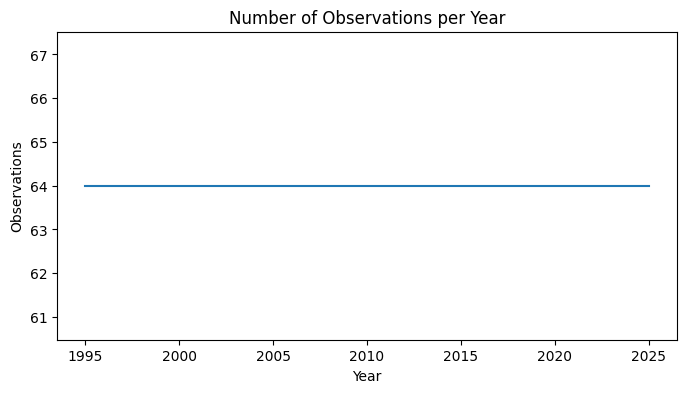

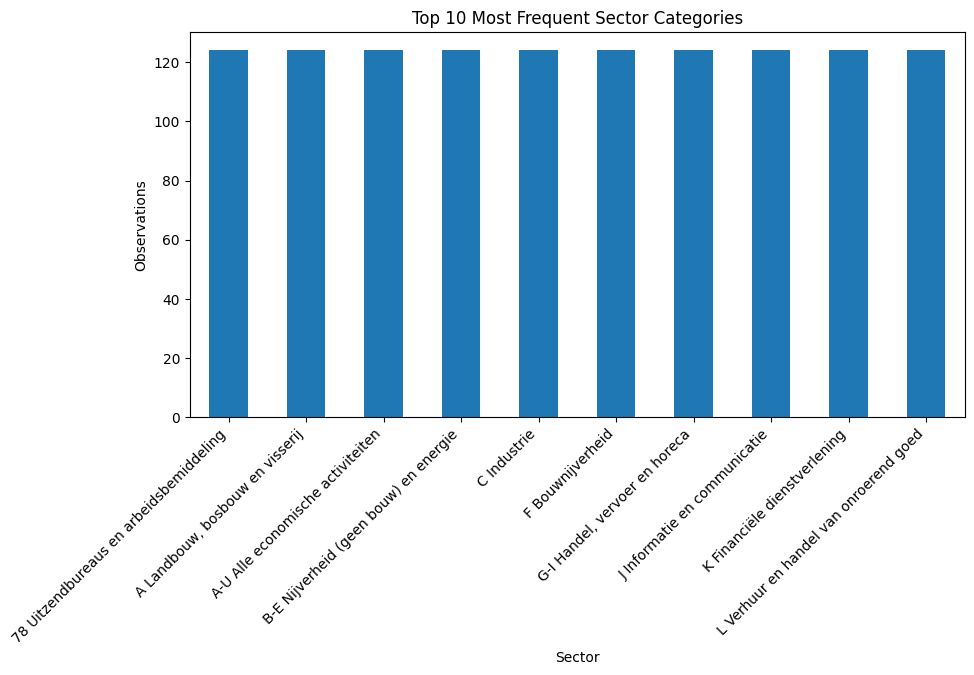

In [10]:
# --------------------------------
# Dataset overview (85917NED)
# --------------------------------

import matplotlib.pyplot as plt


# 1. Dataset size
print("Rows:", df_85917NED_clean.shape[0])
print("Columns:", df_85917NED_clean.shape[1])


# 2. Time coverage
print("\nTime coverage:")
print("Start:", df_85917NED_clean["period_enddate"].min())
print("End:", df_85917NED_clean["period_enddate"].max())

print("\nUnique years:")
print(df_85917NED_clean["year"].nunique())


# 3. Sector coverage
print("\nNumber of unique sectors:")
print(df_85917NED_clean["BedrijfstakkenBranchesSBI2008_Title"].nunique())

print("\nExample sectors:")
print(
    df_85917NED_clean["BedrijfstakkenBranchesSBI2008_Title"]
    .unique()[:10]
)


# 4. Sector structure check (IMPORTANT FOR THIS TABLE)
print("\nSector frequency (top 15):")
print(
    df_85917NED_clean["BedrijfstakkenBranchesSBI2008_Title"]
    .value_counts()
    .head(15)
)


# 5. Observations per year
print("\nObservations per year:")
print(
    df_85917NED_clean.groupby("year").size()
)


# 6. Missing values overview
print("\nMissing values per column:")
print(
    df_85917NED_clean
    .isna()
    .sum()
    .sort_values(ascending=False)
)


# --------------------------------
# VISUALS
# --------------------------------

# 7. Observations per year visualization
plt.figure(figsize=(8,4))

df_85917NED_clean.groupby("year").size().plot()

plt.title("Number of Observations per Year")
plt.xlabel("Year")
plt.ylabel("Observations")

plt.show()


# 8. Sector distribution (top sectors)
plt.figure(figsize=(10,5))

df_85917NED_clean["BedrijfstakkenBranchesSBI2008_Title"]\
    .value_counts()\
    .head(10)\
    .plot(kind="bar")

plt.title("Top 10 Most Frequent Sector Categories")
plt.xlabel("Sector")
plt.ylabel("Observations")

plt.xticks(rotation=45, ha="right")

plt.show()

### Labour Cost vs Time (RAW vs SEASONAL)

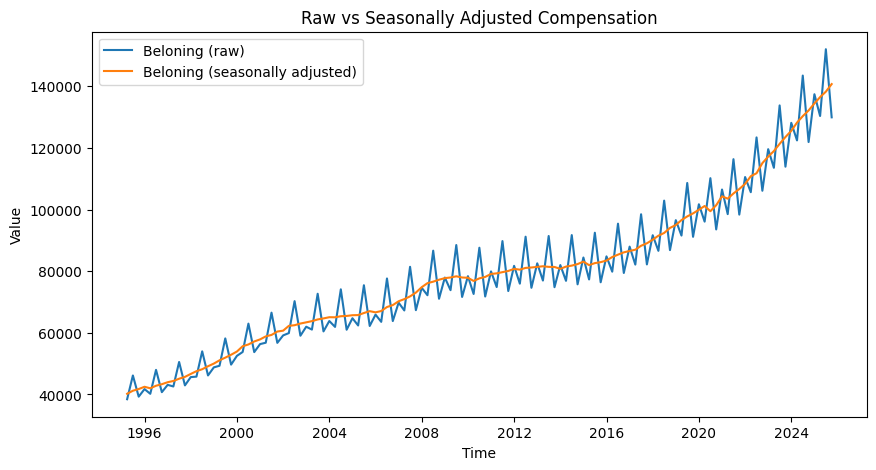

In [12]:
plt.figure(figsize=(10,5))

plt.plot(
    df_total["period_enddate"],
    df_total["BeloningVanWerknemers"],
    label="Beloning (raw)"
)

plt.plot(
    df_total["period_enddate"],
    df_total["BeloningSeizoengecorrigeerd"],
    label="Beloning (seasonally adjusted)"
)

plt.title("Raw vs Seasonally Adjusted Compensation")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()

plt.show()

##### Insight - Labour Cost vs Time (RAW vs SEASONAL)

Compensation exhibits strong seasonal cycles and sustained growth, indicating structural wage pressure and periodic workload dynamics relevant for absenteeism

### Cost Pressure per Hour

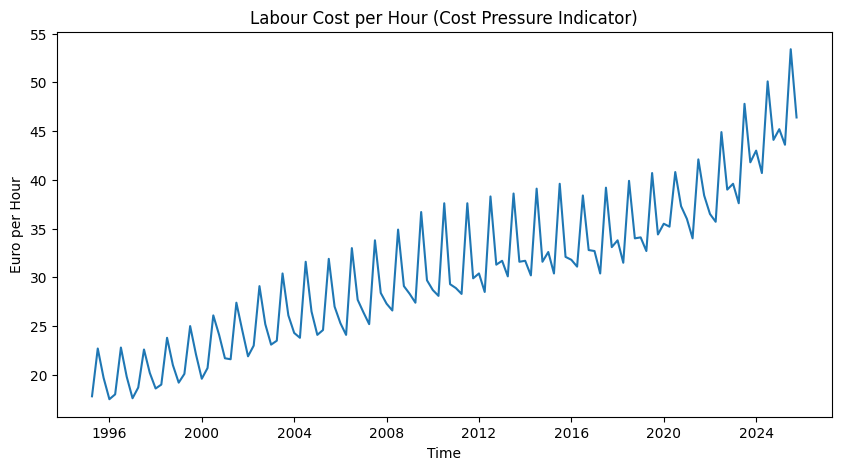

In [15]:
df_total = df_85917NED_clean[
    df_85917NED_clean["BedrijfstakkenBranchesSBI2008_Title"] 
    == "A-U Alle economische activiteiten"
].sort_values("period_enddate")

plt.figure(figsize=(10,5))

plt.plot(
    df_total["period_enddate"],
    df_total["LoonkostenPerGewerktUur"]
)

plt.title("Labour Cost per Hour (Cost Pressure Indicator)")
plt.xlabel("Time")
plt.ylabel("Euro per Hour")

plt.show()

##### Cost Pressure per Hour

While working hours per job remain stable, labour cost per hour has increased significantly, suggesting rising pressure intensity per unit of work — a potential driver of stress-related absenteeism

### Labour Cost per Hour by Sector

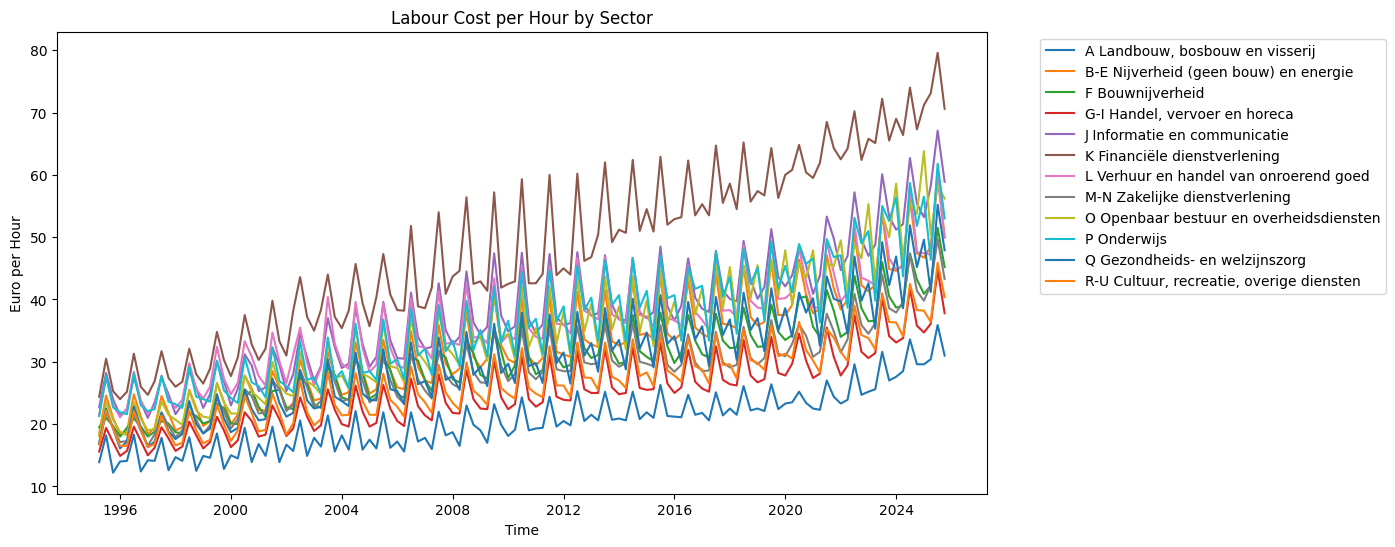

In [18]:
selected_sectors = [
    "A Landbouw, bosbouw en visserij",
    "B-E Nijverheid (geen bouw) en energie",
    "F Bouwnijverheid",
    "G-I Handel, vervoer en horeca",
    "J Informatie en communicatie",
    "K Financiële dienstverlening",
    "L Verhuur en handel van onroerend goed",
    "M-N Zakelijke dienstverlening",
    "O Openbaar bestuur en overheidsdiensten",
    "P Onderwijs",
    "Q Gezondheids- en welzijnszorg",
    "R-U Cultuur, recreatie, overige diensten"
]

df_sectors = df_85917NED_clean[
    df_85917NED_clean["BedrijfstakkenBranchesSBI2008_Title"]
    .isin(selected_sectors)
].sort_values("period_enddate")

plt.figure(figsize=(12,6))

for sector in selected_sectors:
    temp = df_sectors[
        df_sectors["BedrijfstakkenBranchesSBI2008_Title"] == sector
    ]
    
    plt.plot(
        temp["period_enddate"],
        temp["LoonkostenPerGewerktUur"],
        label=sector
    )

plt.title("Labour Cost per Hour by Sector")
plt.xlabel("Time")
plt.ylabel("Euro per Hour")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.show()


#### Insight - Labour Cost per Hour by Sector

Labour cost per hour differs significantly across sectors, with high-skilled sectors (e.g. finance, ICT) showing the highest levels and fastest growth, indicating uneven pressure dynamics across the economy.

Latest valid date: 2025-09-30 00:00:00


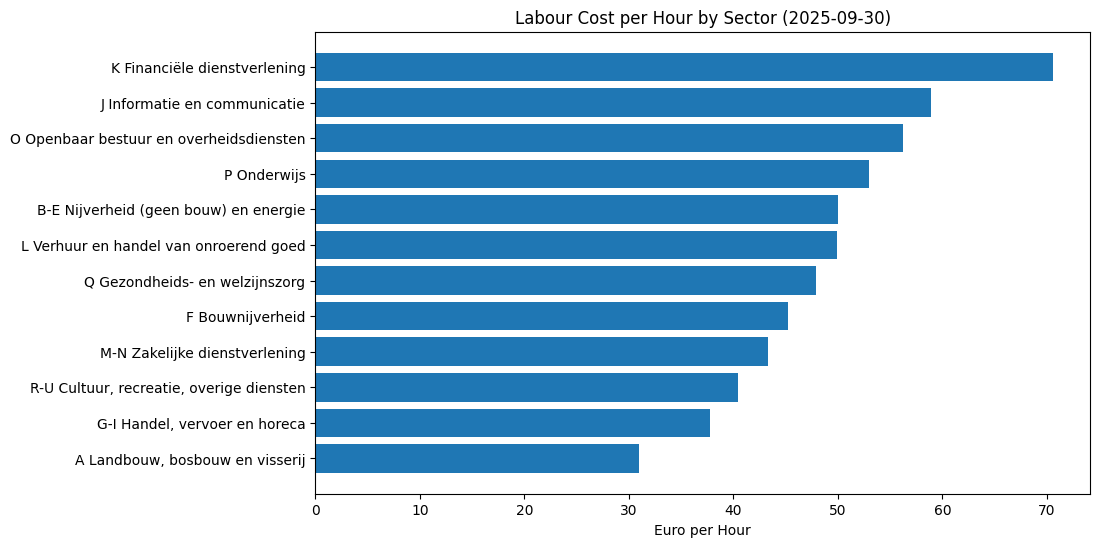

In [27]:
# Filter relevant sectors
df_filtered = df_85917NED_clean[
    df_85917NED_clean["BedrijfstakkenBranchesSBI2008_Title"].isin(selected_sectors)
]

# Remove NaNs for the metric
df_valid = df_filtered.dropna(subset=["LoonkostenPerGewerktUur"])

# Find latest valid date
latest_valid_date = df_valid["period_enddate"].max()

print("Latest valid date:", latest_valid_date)

df_latest = df_valid[
    df_valid["period_enddate"] == latest_valid_date
]

# Sort
df_latest = df_latest.sort_values(
    "LoonkostenPerGewerktUur",
    ascending=False
)

plt.figure(figsize=(10,6))

plt.barh(
    df_latest["BedrijfstakkenBranchesSBI2008_Title"],
    df_latest["LoonkostenPerGewerktUur"]
)

plt.gca().invert_yaxis()
plt.title(f"Labour Cost per Hour by Sector ({latest_valid_date.date()})")
plt.xlabel("Euro per Hour")

plt.show()

#### Insight - Labour Cost per Hour by Sector
Labour cost per hour varies strongly across sectors, with finance and ICT at the top, indicating significantly higher pressure environments compared to sectors like agriculture and horeca.

C:\Users\gebruiker\AppData\Local\Temp\ipykernel_34104\2506661054.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("BedrijfstakkenBranchesSBI2008_Title")\
C:\Users\gebruiker\AppData\Local\Temp\ipykernel_34104\2506661054.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("BedrijfstakkenBranchesSBI2008_Title")\


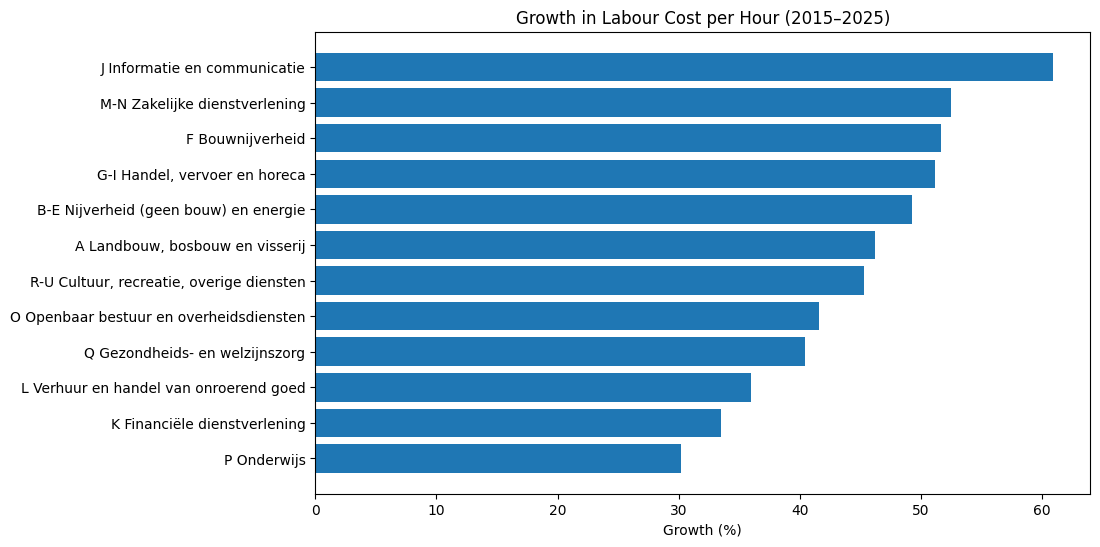

In [30]:
# Select years
year_start = 2015
year_end = 2025

df_growth = df_85917NED_clean[
    df_85917NED_clean["BedrijfstakkenBranchesSBI2008_Title"].isin(selected_sectors)
]

# Keep valid data
df_growth = df_growth.dropna(subset=["LoonkostenPerGewerktUur"])


# Get latest per sector per year
df_start = df_growth[df_growth["year"] == year_start]\
    .sort_values("period_enddate")\
    .groupby("BedrijfstakkenBranchesSBI2008_Title")\
    .tail(1)

df_end = df_growth[df_growth["year"] == year_end]\
    .sort_values("period_enddate")\
    .groupby("BedrijfstakkenBranchesSBI2008_Title")\
    .tail(1)


# Merge
df_merge = df_start.merge(
    df_end,
    on="BedrijfstakkenBranchesSBI2008_Title",
    suffixes=("_start", "_end")
)

# Calculate growth
df_merge["growth_pct"] = (
    (df_merge["LoonkostenPerGewerktUur_end"] -
     df_merge["LoonkostenPerGewerktUur_start"]) /
     df_merge["LoonkostenPerGewerktUur_start"]
) * 100

# Sort
df_merge = df_merge.sort_values("growth_pct", ascending=False)


# Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    df_merge["BedrijfstakkenBranchesSBI2008_Title"],
    df_merge["growth_pct"]
)

plt.gca().invert_yaxis()
plt.title("Growth in Labour Cost per Hour (2015–2025)")
plt.xlabel("Growth (%)")

plt.show()

#### Insight - Labour Cost per Hour by Sector (Growth)

Labour cost pressure has increased across all sectors, but unevenly — with knowledge-intensive sectors showing the strongest growth.

Highest growth (~50–60%)
→ Information & communication, business services, construction
Moderate growth (~40–50%)
→ Industry, trade, agriculture
Lowest growth (~30–40%)
→ Public sector, education, finance

### Productivity / Workload Proxy

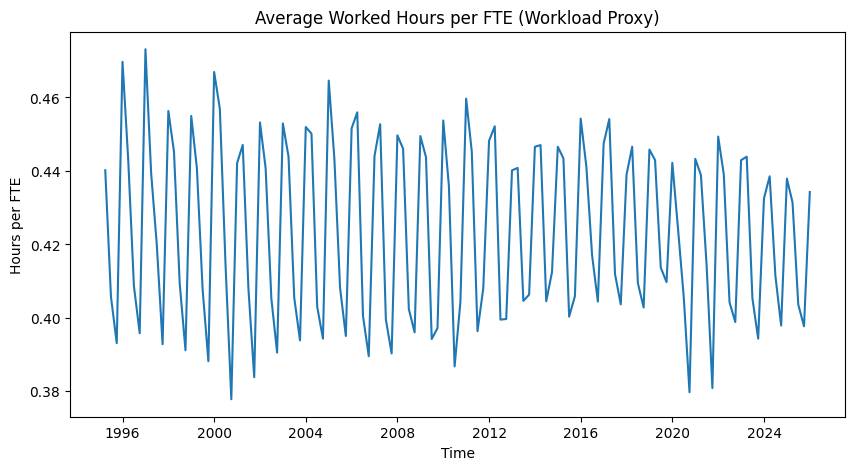

In [31]:
df_total = df_85917NED_clean[
    df_85917NED_clean["BedrijfstakkenBranchesSBI2008_Title"] == 
    "A-U Alle economische activiteiten"
].copy()

df_total["hours_per_fte"] = (
    df_total["GewerkteUren"] / df_total["Arbeidsjaren"]
)


plt.figure(figsize=(10,5))

plt.plot(
    df_total["period_enddate"],
    df_total["hours_per_fte"]
)

plt.title("Average Worked Hours per FTE (Workload Proxy)")
plt.xlabel("Time")
plt.ylabel("Hours per FTE")

plt.show()


#### Productivity / Workload Proxy
Workload per employee has remained broadly stable over time, with strong seasonal patterns but no structural increase.

### Premium Share

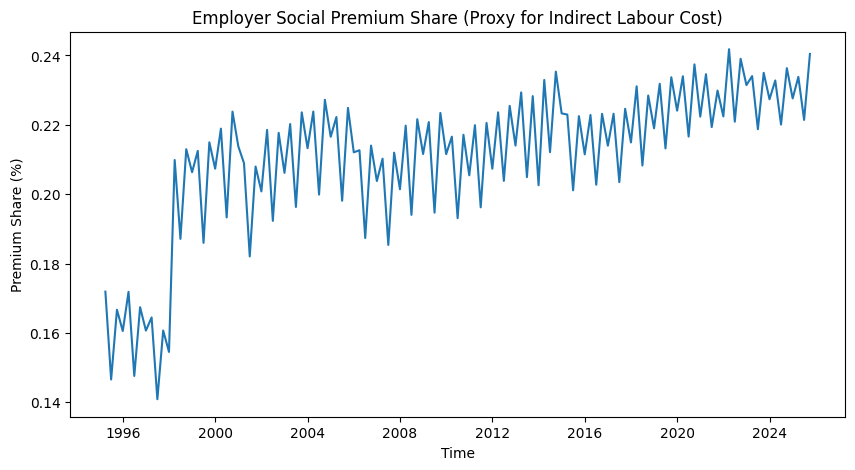

In [32]:
df_total = df_85917NED_clean[
    df_85917NED_clean["BedrijfstakkenBranchesSBI2008_Title"] == 
    "A-U Alle economische activiteiten"
].copy()

df_total["premium_share"] = (
    df_total["SocialePremiesTLVWerkgevers"] /
    df_total["BeloningVanWerknemers"]
)

plt.figure(figsize=(10,5))

plt.plot(
    df_total["period_enddate"],
    df_total["premium_share"]
)

plt.title("Employer Social Premium Share (Proxy for Indirect Labour Cost)")
plt.xlabel("Time")
plt.ylabel("Premium Share (%)")

plt.show()

#### Insight - Premium Share
While workload remains stable, employer-paid social premiums have steadily increased — pointing to a growing structural burden likely linked to sickness and absenteeism.

### Labour Market Stress by Sector

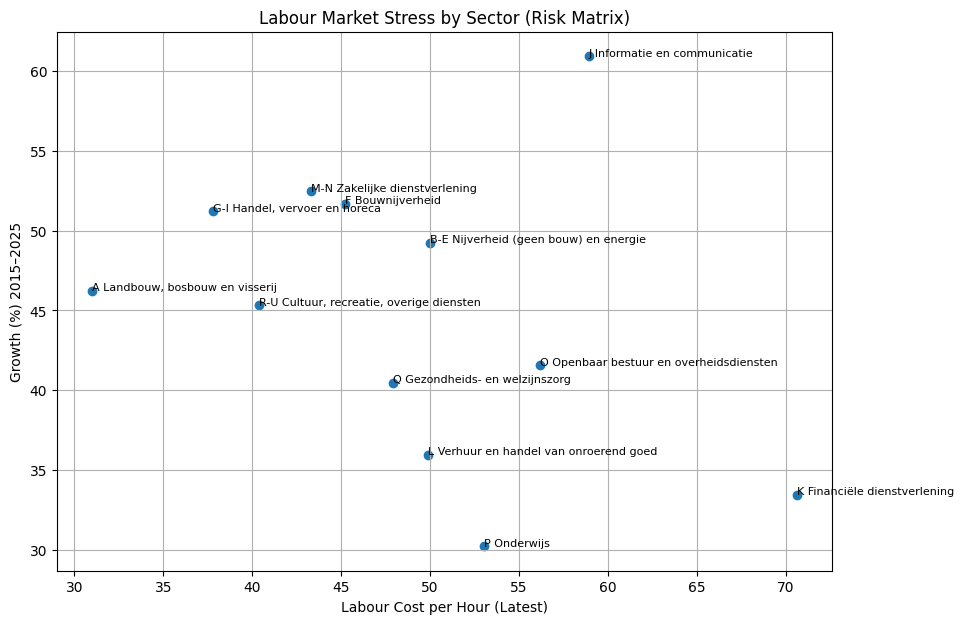

In [33]:
df_merge["latest_cost"] = df_merge["LoonkostenPerGewerktUur_end"]

plt.figure(figsize=(10,7))

plt.scatter(
    df_merge["latest_cost"],
    df_merge["growth_pct"]
)

# Add labels
for i, row in df_merge.iterrows():
    plt.text(
        row["latest_cost"],
        row["growth_pct"],
        row["BedrijfstakkenBranchesSBI2008_Title"],
        fontsize=8
    )

plt.title("Labour Market Stress by Sector (Risk Matrix)")
plt.xlabel("Labour Cost per Hour (Latest)")
plt.ylabel("Growth (%) 2015–2025")

plt.grid(True)

plt.show()

#### Insight - Labour Market Stress by Sector

Labour market stress is most pronounced in knowledge-intensive and service sectors, where both wage levels and growth are high — indicating elevated absenteeism risk.

# Summary and Key Insights

The results indicate that absenteeism risk is concentrated in sectors with both high and rapidly increasing labor costs, particularly in knowledge-intensive and service industries. Combined with stable workload levels and rising employer premium shares, this points to structural factors—such as labor shortages and increasing sickness-related costs—as key drivers. These insights support a targeted, sector-specific approach to absenteeism prediction and intervention.